In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [5]:
SEED = 9091989
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Dispositivo     : {device}")
print("Entorno listo.")

PyTorch version : 2.5.1
Dispositivo     : cpu
Entorno listo.


#### Pregunta 0.1 ¿Por qué fijamos SEED =... al principio y no al final, ni en ningún otro momento? ¿Qué procesos dentro del entrenamiento de una red neuronal son probabilistas y se verían afectados si no hubieras fijado la semilla?

#### Pregunta 0.2 La celda imprime el dispositivo. La gran mayoría de ustedes verá cpu. ¿Por qué para este problema específico (1,030 muestras, 8 features, red pequeña) eso no es un problema? ¿En qué tipo de problema sí necesitarías GPU?

In [9]:
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df = pd.read_excel(url)
df.columns = [
    "cemento", "escoria", "ceniza", "agua",
    "superplast", "agregado_grueso", "agregado_fino",
    "edad", "resistencia"
]

print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)

Dimensiones: (1030, 9)

Valores nulos:
cemento            0
escoria            0
ceniza             0
agua               0
superplast         0
agregado_grueso    0
agregado_fino      0
edad               0
resistencia        0
dtype: int64

Estadísticas descriptivas:


,cemento,escoria,ceniza,agua,superplast,agregado_grueso,agregado_fino,edad,resistencia
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


Pregunta El dataset tiene 1,030 observaciones. GPT-3 fue entrenado con aproximadamente 300 mil millones de tokens. ¿Qué implica esa diferencia de escala para la elección entre una red neuronal profunda y un modelo lineal? Antes de ver los resultados de esta actividad...qué esperas encontrar?


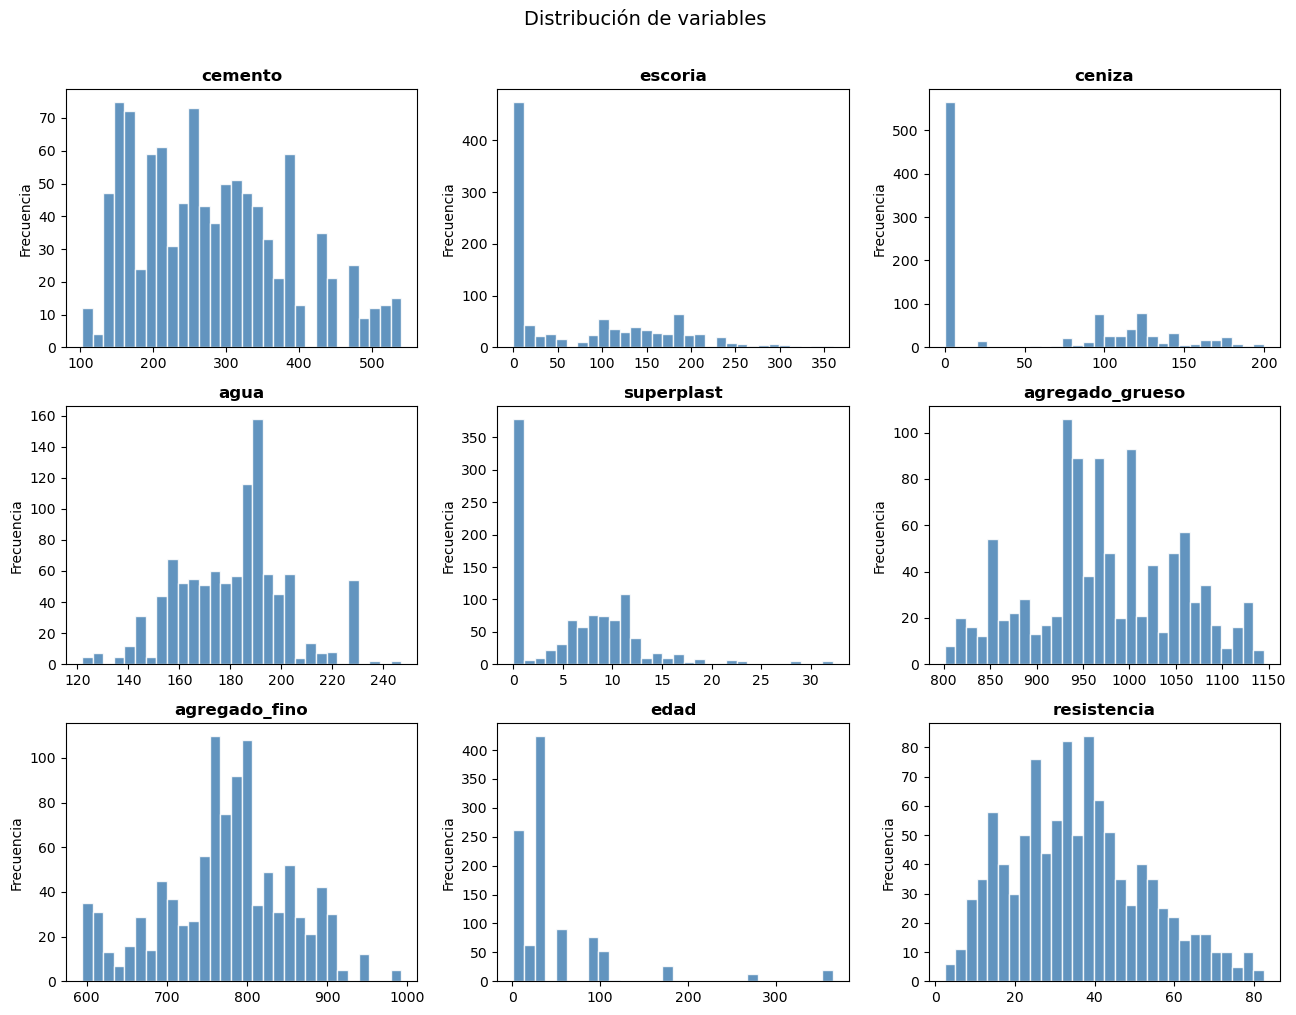

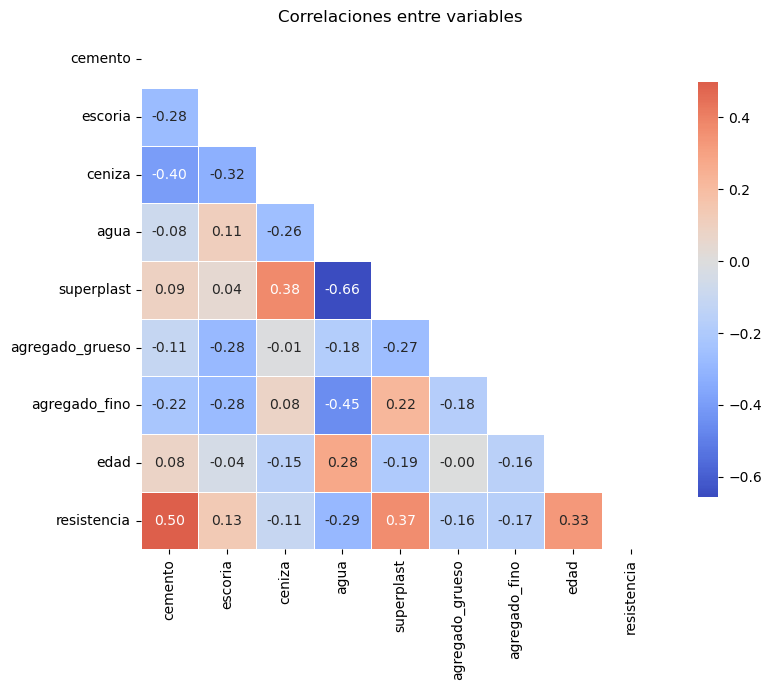

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones entre variables")
plt.tight_layout()
plt.show()

#### Pregunta 1.2 Observa el histograma de edad. Describe su distribución. ¿Es aproximadamente normal? ¿Por qué importa la distribución de las variables de entrada antes de pasarlas a una red neuronal?

#### Pregunta 1.3 Mira el mapa de correlaciones. ¿Cuál variable tiene mayor correlación con resistencia? ¿Eso significa que una red neuronal sólo necesitaría esa variable para predecir bien?

In [11]:
X = df.drop("resistencia", axis=1).values   # shape: (1030, 8)
y = df["resistencia"].values.reshape(-1, 1) # shape: (1030, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Val   : {X_val.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]} muestras")

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

Train : 700 muestras
Val   : 124 muestras
Test  : 206 muestras


#### Pregunta 1.4 Esta vez hay tres conjuntos: train, val y test. ¿Cuál es la función específica del conjunto de validación que no puede cumplir el conjunto de prueba? Si usaras el test set para early stopping, ¿qué error conceptual estarías cometiendo?

#### Pregunta 1.5 X_val_sc y X_test_sc usan .transform(), no .fit_transform(). Explica por qué esto es importante en términos de lo que el modelo "puede saber" sobre los datos. ¿Qué nombre tiene este tipo de error cuando se comete?

#### Pregunta 1.6 Estamos escalando también y. Escalar el target no siempre es necesario en regresión lineal, pero en redes neuronales es común. Menciona dos razones técnicas por las que escalar el target puede ayudar al entrenamiento de una red.

In [12]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train_sc)
X_val_t   = to_tensor(X_val_sc)
X_test_t  = to_tensor(X_test_sc)
y_train_t = to_tensor(y_train_sc)
y_val_t   = to_tensor(y_val_sc)
y_test_t  = to_tensor(y_test_sc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Tensor train X : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"Tensor train y : {y_train_t.shape}  dtype={y_train_t.dtype}")

Tensor train X : torch.Size([700, 8])  dtype=torch.float32
Tensor train y : torch.Size([700, 1])  dtype=torch.float32


#### Pregunta 1.7 ¿Por qué usamos float32 y no float64 (doble precisión)? ¿Cuándo el uso de float64 podría ser importante?

#### Pregunta 1.8 DataLoader recibe shuffle=True. En clase viste qué es un epoch (slide 104 del lunes). ¿Por qué tiene sentido mezclar los datos en cada epoch? ¿Qué problema concreto estás evitando?

In [14]:
# Red de verificación (NO es tu modelo final, es solo para verificar el cálculo manual)
x_toy  = torch.tensor([[0.5, -1.0]])
W1 = torch.tensor([[0.3, 0.8], [-0.5, 0.2]])  # PyTorch: filas = neuronas de salida
b1 = torch.tensor([[0.1, -0.3]])
W2 = torch.tensor([[0.6, -0.4]])
b2 = torch.tensor([[0.0]])

z1 = x_toy @ W1.T + b1
a1 = torch.relu(z1)
z2 = a1 @ W2.T + b2

print(f"z1 = {z1}")
print(f"a1 = {a1}")
print(f"z2 (ŷ) = {z2}")
y_toy = torch.tensor([[2.0]])
mse   = ((z2 - y_toy) ** 2).mean()
print(f"MSE = {mse.item():.6f}")

z1 = tensor([[-0.5500, -0.7500]])
a1 = tensor([[0., 0.]])
z2 (ŷ) = tensor([[0.]])
MSE = 4.000000


#### Pregunta 2.1 Muestra aquí tu cálculo manual paso a paso. ¿Coincide con la salida del código? Si hay discrepancia, ¿dónde está el error?

#### Pregunta 2.2 En el paso de ReLU, si Z1[1] hubiera sido negativo, ¿qué valor tomaría A1[1]? ¿Qué implicación tiene eso para el gradiente de esa neurona durante backpropagation? ¿Cómo se llama ese fenómeno?

In [15]:
class ConcreteNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(ConcreteNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

model = ConcreteNet(input_dim=8, hidden_dim=64, output_dim=1, dropout_rate=0.0).to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")

ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros: 4,801


#### Pregunta 2.3 El código imprime el total de parámetros automáticamente. Antes de ejecutar la celda, calcula ese número a mano para la arquitectura 8 -> 64 -> 64 -> 1. Muestra el desglose por capa (pesos + sesgos). ¿Coincide?

#### Pregunta 2.4 La capa de salida no tiene función de activación. ¿Por qué? ¿Qué pasaría si agregáramos ReLU al final en este problema? ¿Podría eso causar un error sistemático en las predicciones?

#### Pregunta 2.5 nn.Sequential es una alternativa a escribir forward() manualmente. ¿Cuándo sería necesario escribir forward() explícitamente en lugar de usar nn.Sequential? Piensa en arquitecturas más complejas.

Shape de W₁: torch.Size([64, 8])
Media de W₁: 0.0037
Std  de W₁: 0.2018
Min  de W₁: -0.3519
Max  de W₁: 0.3502


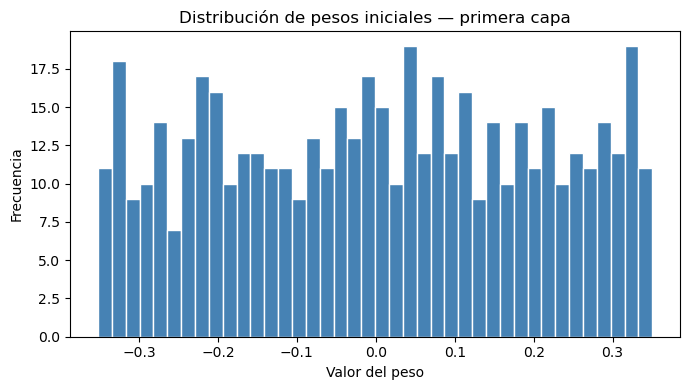

In [16]:
# Observar cómo PyTorch inicializa los pesos
primera_capa = list(model.parameters())[0]  # W de la primera capa: shape (64, 8)
print(f"Shape de W₁: {primera_capa.shape}")
print(f"Media de W₁: {primera_capa.data.mean():.4f}")
print(f"Std  de W₁: {primera_capa.data.std():.4f}")
print(f"Min  de W₁: {primera_capa.data.min():.4f}")
print(f"Max  de W₁: {primera_capa.data.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(primera_capa.data.cpu().numpy().flatten(), bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribución de pesos iniciales — primera capa")
plt.xlabel("Valor del peso")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

#### Pregunta 2.6 ¿Qué distribución tienen los pesos iniciales? PyTorch usa por default la inicialización de Kaiming He para capas con ReLU. ¿Por qué no inicializar todos los pesos en cero? ¿Qué problema fundamental causaría eso durante el entrenamiento? (Pista: piensa en lo que haría backpropagation si todos los pesos fueran idénticos.)

In [17]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

#### Pregunta 3.1 Se usa MSELoss. ¿Por qué MSE y no cross-entropy? ¿En qué tipo de tarea usarías cross-entropy binary y en cuál usarías cross-entropy multiclase?

#### Pregunta 3.2 El optimizador es Adam con lr=1e-3. En clase viste que Adam mantiene estimaciones del primer y segundo momento del gradiente. Explica con tus palabras qué significa que los parámetros que "varían mucho" reciban pasos más pequeños. ¿Por qué eso puede ser ventajoso frente a un learning rate fijo para todos?

In [18]:
def train_model(model, train_loader, X_val_t, y_val_t,
                n_epochs=300, patience=20, verbose_every=25):
    """
    Entrena el modelo con early stopping basado en val loss.
    
    Args:
        patience : cuántos epochs tolerar sin mejora en val loss
                   antes de detener el entrenamiento.
    Returns:
        Historial de train loss y val loss por epoch.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    train_history = []
    val_history   = []
    
    # Variables para early stopping
    best_val_loss   = float("inf")
    best_weights    = None
    epochs_no_improv = 0
    stopped_at      = n_epochs
    
    for epoch in range(n_epochs):
        
        # ── MODO ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            
            # Paso 1: limpiar gradientes acumulados
            optimizer.zero_grad()
            
            # Paso 2: forward pass
            y_pred = model(X_batch)
            
            # Paso 3: calcular pérdida
            loss = criterion(y_pred, y_batch)
            
            # Paso 4: backward pass (calcular gradientes)
            loss.backward()
            
            # Paso 5: actualizar pesos
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        train_loss = np.mean(batch_losses)
        train_history.append(train_loss)
        
        # ── MODO EVALUACIÓN ─────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_history.append(val_loss)
        
        # ── EARLY STOPPING ──────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
        
        if epochs_no_improv >= patience:
            stopped_at = epoch + 1
            print(f"  Early stopping en epoch {stopped_at}.")
            break
        
        if (epoch + 1) % verbose_every == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    
    # Restaurar los mejores pesos encontrados
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return train_history, val_history, stopped_at


# Entrenamiento
print("Entrenando modelo base...")
train_hist, val_hist, stopped = train_model(model, train_loader, X_val_t, y_val_t)
print(f"Entrenamiento completado. Detenido en epoch {stopped}.")

Entrenando modelo base...
  Epoch  25 | Train: 0.0916 | Val: 0.1374
  Epoch  50 | Train: 0.0543 | Val: 0.1169
  Epoch  75 | Train: 0.0419 | Val: 0.1100
  Epoch 100 | Train: 0.0344 | Val: 0.1070
  Early stopping en epoch 114.
Entrenamiento completado. Detenido en epoch 114.


#### Pregunta 3.3 — La más importante de esta sección. Explica con tus propias palabras qué hace cada uno de los 5 pasos dentro del loop de batches. No copies las definiciones de los slides: formula la explicación en términos de lo que está ocurriendo matemáticamente con los pesos de esta red específica, con este dataset concreto.

#### Pregunta 3.4 optimizer.zero_grad() está dentro del loop de batches, no fuera. ¿Qué pasaría si lo movieras fuera del loop (es decir, que se ejecutara solo una vez al inicio de cada epoch)? ¿Los pesos se actualizarían correctamente?

#### Pregunta 3.5 El bloque de evaluación usa model.eval() y torch.no_grad(). Son dos cosas distintas:
- model.eval() cambia el comportamiento de ciertas capas. ¿Cuáles capas de tu modelo se comportan diferente en modo evaluación vs entrenamiento, y por qué?
- torch.no_grad() evita que PyTorch construya el grafo computacional. ¿Qué es ese grafo y para qué lo usa backpropagation? ¿Por qué no lo necesitas durante la evaluación?

#### Pregunta 3.6 El early stopping implementado guarda best_weights y los restaura al final con model.load_state_dict(best_weights). ¿Por qué es necesario ese paso de restauración? ¿Qué le estarías devolviendo al usuario si no lo hicieras?

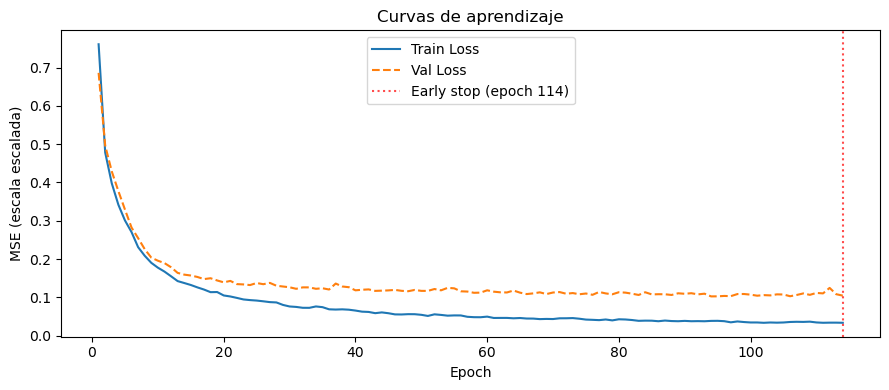

In [19]:
def plot_learning_curves(train_hist, val_hist, stopped_at, title="Curvas de aprendizaje"):
    plt.figure(figsize=(9, 4))
    epochs = range(1, len(train_hist) + 1)
    plt.plot(epochs, train_hist, label="Train Loss", linewidth=1.5)
    plt.plot(epochs, val_hist,   label="Val Loss",   linewidth=1.5, linestyle="--")
    plt.axvline(x=stopped_at, color="red", linestyle=":", alpha=0.7,
                label=f"Early stop (epoch {stopped_at})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (escala escalada)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(train_hist, val_hist, stopped)

#### Pregunta 3.7 Pega tu gráfica aquí y describe lo que ves. Responde específicamente: a) ¿El val loss converge suavemente o tiene ruido? ¿A qué atribuyes eso? b) ¿Hay señal de overfitting? ¿Cómo lo identificas visualmente — no con un número, sino con la forma de las curvas? c) ¿La línea de early stopping está "en el lugar correcto", o debería haber esperado más o parado antes?

In [20]:
def evaluate(model, X_t, y_true_sc, scaler_y, label=""):
    model.eval()
    with torch.no_grad():
        y_pred_sc = model(X_t).cpu().numpy()
    y_pred_mpa = scaler_y.inverse_transform(y_pred_sc)
    y_true_mpa = scaler_y.inverse_transform(y_true_sc)
    rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    mae  = np.mean(np.abs(y_true_mpa - y_pred_mpa))
    if label:
        print(f"{label:30s} | RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa")
    return rmse, mae, y_pred_mpa, y_true_mpa

rmse_nn, mae_nn, y_pred_mpa, y_true_mpa = evaluate(
    model, X_test_t, y_test_sc, scaler_y, "Red Neuronal (base)"
)

Red Neuronal (base)            | RMSE: 5.22 MPa | MAE: 3.61 MPa


#### Pregunta 4.1 Reportas tanto RMSE como MAE. ¿En qué se diferencian conceptualmente? Si el RMSE es notablemente mayor que el MAE, ¿qué sugiere eso sobre los errores del modelo?

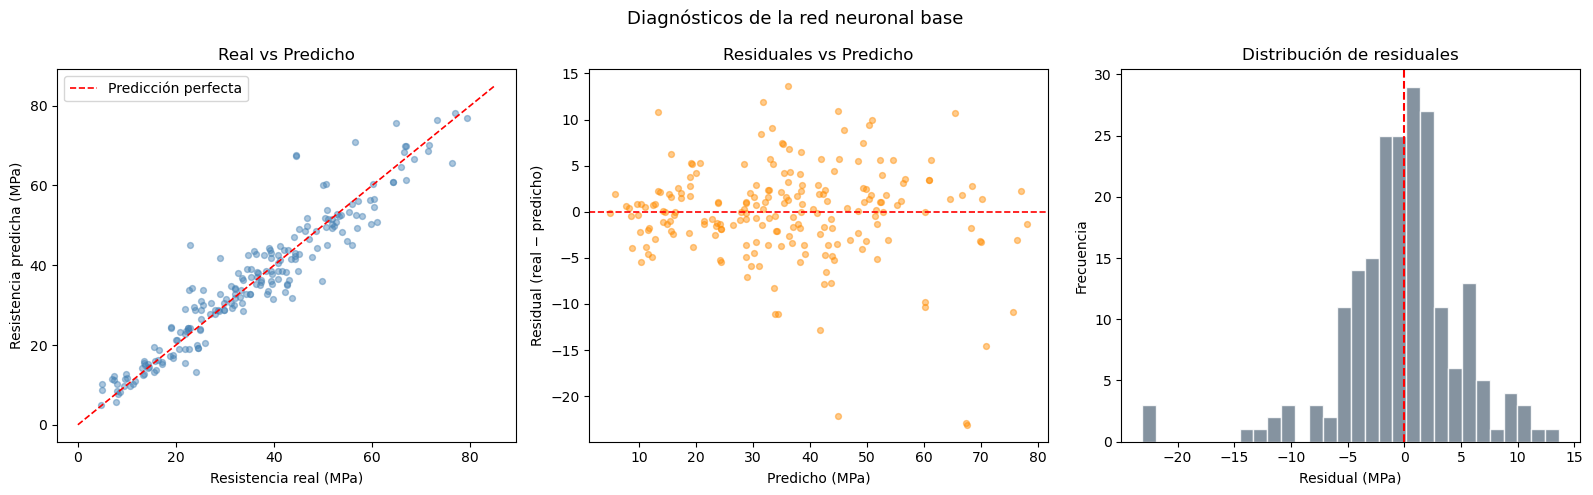

Media de residuales  : -0.199
Std  de residuales   : 5.213


In [21]:
residuals = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Real vs Predicho
ax = axes[0]
ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.45, s=18, color="steelblue")
lims = [0, 85]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Resistencia real (MPa)")
ax.set_ylabel("Resistencia predicha (MPa)")
ax.set_title("Real vs Predicho")
ax.legend()

# Gráfica 2: Residuales vs Predicho
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.45, s=18, color="darkorange")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicho (MPa)")
ax.set_ylabel("Residual (real − predicho)")
ax.set_title("Residuales vs Predicho")

# Gráfica 3: Distribución de residuales
ax = axes[2]
ax.hist(residuals, bins=30, color="slategray", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuales")

plt.suptitle("Diagnósticos de la red neuronal base", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media de residuales  : {residuals.mean():.3f}")
print(f"Std  de residuales   : {residuals.std():.3f}")

#### Pregunta 4.2 Pega las tres gráficas. Para cada una, escribe al menos dos observaciones:
- Real vs Predicho: ¿hay sesgo sistemático? ¿el modelo predice igual de bien en valores bajos que en valores altos de resistencia?
- Residuales vs Predicho: ¿hay homocedasticidad o el patrón de los errores cambia con el valor predicho?
- Distribución de residuales: ¿es aproximadamente simétrica? ¿hay outliers evidentes?

#### Pregunta 4.3 El supuesto de normalidad de residuales importaba mucho en regresión lineal para inferencia estadística (intervalos de confianza, p-values). En una red neuronal entrenada por minimización de MSE, ¿ese supuesto sigue siendo necesario? ¿Qué sí y qué no cambia?

In [22]:
def experimento_lr(lr_list, n_epochs=300):
    resultados = {}
    for lr in lr_list:
        m = ConcreteNet(8, 64, 1, dropout_rate=0.0).to(device)
        opt = optim.Adam(m.parameters(), lr=lr)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in train_loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        resultados[lr] = (hist_train, hist_val)
        print(f"  lr={lr:.0e} | Val Loss final: {hist_val[-1]:.4f}")
    return resultados

print("Experimento: learning rate")
res_lr = experimento_lr([1e-1, 1e-2, 1e-3, 1e-4])

Experimento: learning rate
  lr=1e-01 | Val Loss final: 0.1679
  lr=1e-02 | Val Loss final: 0.0716
  lr=1e-03 | Val Loss final: 0.1113
  lr=1e-04 | Val Loss final: 0.1259
